In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dataset Iris: 150 bunga, 4 fitur, 3 kelas (setosa, versicolor, virginica).
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# Logistic Regression: model statistik yang menghitung probabilitas tiap kelas.
lr = LogisticRegression(max_iter=200).fit(X_train, y_train)

# Decision Tree: model pohon keputusan yang memecah data berdasarkan aturan if-else.
dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)

# Loop untuk mengevaluasi kedua model sekaligus.
for name, model in {"LogReg": lr, "DecisionTree": dt}.items():
    pred = model.predict(X_test)
    print(f"\n{name} accuracy:", round(accuracy_score(y_test, pred), 3))
    print(confusion_matrix(y_test, pred))           # tabel prediksi vs aktual
    print(classification_report(y_test, pred, target_names=iris.target_names))  # precision, recall, F1


LogReg accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


DecisionTree accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#Tujuan Pratikm
Pratikum ini bertujuan untuk melakukan persiapan data (preprocessing) dari bentuk kategori ke nuerik lalu kemudian mengimplementasikan algoritma Logistic Regresion dan Decision Tree untuk klasifikasi serta mengevaluasi performa model menggunakan Confusion Matrik dan menganalisis hasil akurasi melalui metrik F1-Score.

#Langkah Kerja
1. Memuat dataset dan melakukan mapping pada kolom non-numerik.
2. Membagi data menjadi training Set dan Test Set.
3. Melatih model Logistic Regression dan Decision Tree.
4. Menampilkan visualisasi Confusion Matrix.
5. Memvisualisasikan struktur pohon keputusan.
6. Membandingkan metrix evaluasi.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

# ============================================================
# LOAD DATASET TIPS
# ============================================================
df = sns.load_dataset('tips')

# ============================================================
# PREPROCESSING DATA
# ============================================================
df_clf = df.copy()
df_clf['smoker'] = df_clf['smoker'].map({'Yes': 1, 'No': 0})
df_clf['sex'] = df_clf['sex'].map({'Female': 0, 'Male': 1})
df_clf['time'] = df_clf['time'].map({'Lunch': 0, 'Dinner': 1})
df_clf['day'] = df_clf['day'].astype('category').cat.codes

X = df_clf[['total_bill', 'tip', 'size', 'sex', 'time', 'day']]
y = df_clf['smoker']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Pada program ini digunakan untuk mengubah data teks menjadi angka agar bisa dihitung oleh model. Kemudian datanya dibagi menjadi dua 80% digunakan untuk data latih sedangkan 20% digunakan untuk data uji.
Dari hasil proses ini variabel data yang sudah siap. Pada kolom seperti day dan time yang tadinya teks kini sudah menjadi angka.

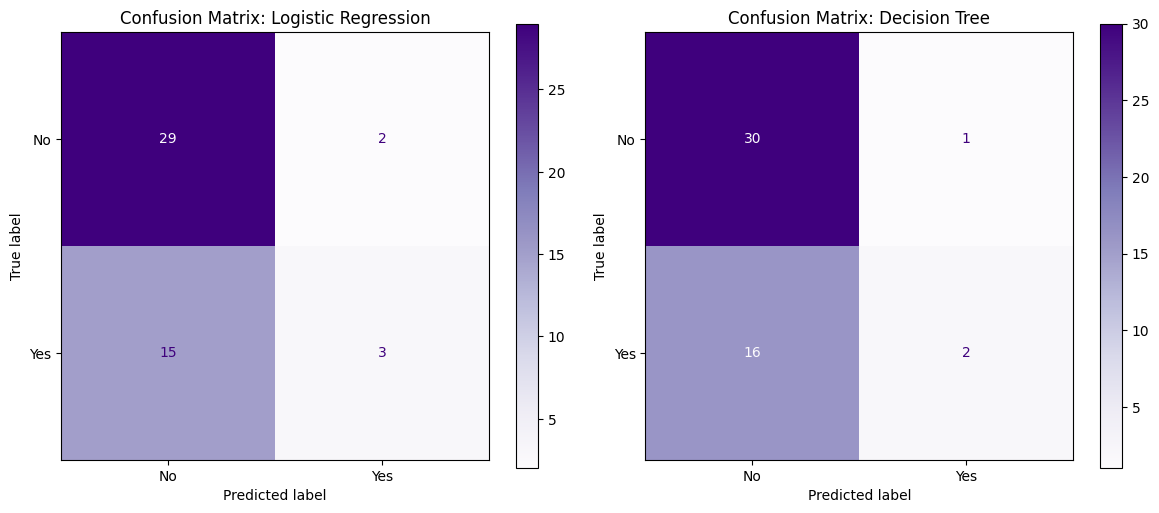

=== VISUALISASI STRUCTURE DECISION TREE ===


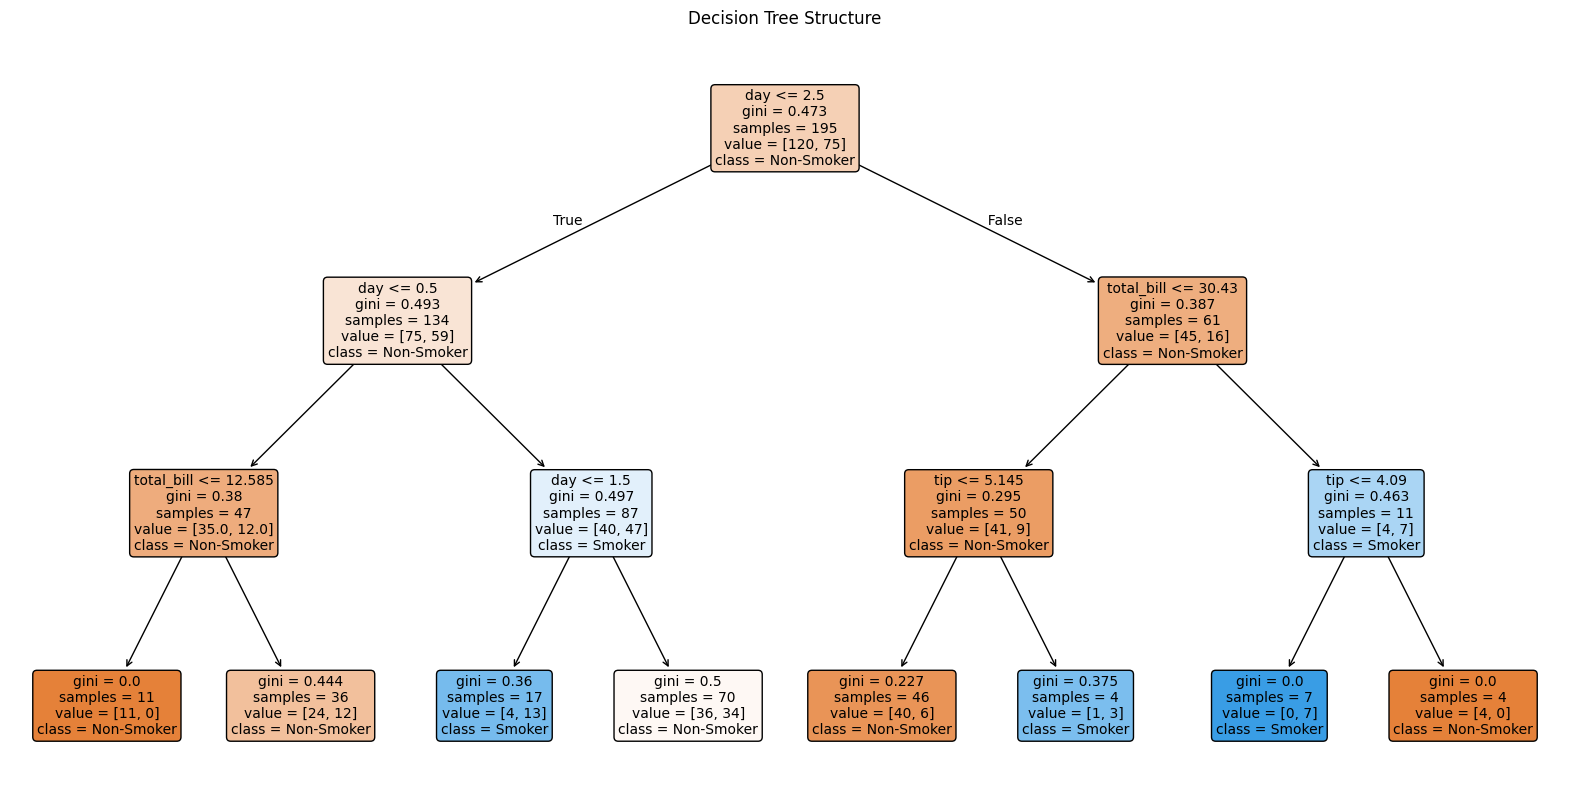

In [6]:
# ============================================================
# 1. JALANKAN 2 MODEL
# ============================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42)
}

results = {}

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }

     # ============================================================
    # 3. CONFUSION MATRIX
    # ============================================================
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax[i], cmap='Purples')
    ax[i].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()


    # ============================================================
# VISUALISASI DECISION TREE
# ============================================================
print("=== VISUALISASI STRUCTURE DECISION TREE ===")
plt.figure(figsize=(20,10))
plot_tree(models["Decision Tree"],
          feature_names=X.columns,
          class_names=['Non-Smoker', 'Smoker'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Structure")
plt.show()

Pada bagian ini, saya mendefinisikan dua algoritma klasifikasi yaitu Logistic Regression dan Decision Tree (menampilkan alur logika bagaimna model Decision Tree mengambil keputusan). Kedua ,model ini dilatih menggunakan data x_train untuk mengenali pola perokok.
Hasil dari outpunya adalah model Logistic Regression sudah bisa membedakan ciri - ciri pelanggan yang merokok dan tidak merokok berdasarkan data yang diberikan. Sedangkan diagram pohon keputusan ini menunjukkan fitur apa saja yang paling penting ( berada paling atas) dimana tujuannya yaitu untuk menentukan apkah seseorang itu perokok atau tidak.

In [4]:
# ============================================================
# 2. PERBANDINGAN METRIK
# ============================================================
print("\n=== PERBANDINGAN METRIK MODEL ===")
df_results = pd.DataFrame(results).T
print(df_results)


=== PERBANDINGAN METRIK MODEL ===
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.653061   0.600000  0.166667  0.260870
Decision Tree        0.653061   0.666667  0.111111  0.190476


Program ini digunkan untuk menjalankan model, program ini menamampilkan ringkasan performa dalam bentuk tabel agar mudah dibandingkan.
Dari hasil outputnya yaitu berisi angka Accuracy, Precision, Recall, dan F1-Score. Dari tabel ini, kita bisa melihat secara objektif model mana yang lebih unggul.

In [7]:
# ============================================================
# 4. KESIMPULAN BERDASARKAN F1-SCORE
# ============================================================
best_model = df_results['F1-Score'].idxmax()

print("\nKESIMPULAN:")
print(f"Model terbaik adalah {best_model}")
print("Alasan:")
print("- Model tersebut memiliki nilai Accuracy, Precision, Recall, dan F1-Score yang lebih baik.")
print("- F1-Score dipilih sebagai acuan utama karena mempertimbangkan keseimbangan antara Precision dan Recall.")
print("- Sehingga model tersebut lebih stabil dalam mengklasifikasikan data smoker dan non-smoker.")


KESIMPULAN:
Model terbaik adalah Logistic Regression
Alasan:
- Model tersebut memiliki nilai Accuracy, Precision, Recall, dan F1-Score yang lebih baik.
- F1-Score dipilih sebagai acuan utama karena mempertimbangkan keseimbangan antara Precision dan Recall.
- Sehingga model tersebut lebih stabil dalam mengklasifikasikan data smoker dan non-smoker.


Program ini yaitu digunakan untuk memberikan keputusan akhir mengenai model mana yang paling direkomendasikan.
Dari hasil outputnya secra otomatis program ini memilih model dengan F1-Score tertinggi. Menganpa begitu karena F1-Score lebih adil dalam menilai akurasi jika jumlah data perokok dan tidak perokok tidak seimbang.

#Kesimpulan
Dari pratikum ini, dapat saya simpulkan bahwa tahap preprocessing sangat menentukan hasil akhir. Melalui perbandingan metrix, kita dapat mengetahui bahwa model Logistic Regression lebih efektif digunakan untuk dataset ini. kemudian visualisasi dengan Confusion Matrix dan Decision Tree mempermudah kita dalam memahami cara kerja model secara mendalam.
